In [1]:
import os
import glob
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models
from IPython import display

# Set the seed value for experiment reproducibility.
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

import warnings
warnings.filterwarnings("ignore")

In [2]:
FRAME_LENGTH = 255
FRAME_STEP = 128

class Spectrogram():

  def __init__(self):
    pass


  def get_spectrogram(self, waveform):
    spectrogram = tf.signal.stft(
        waveform, frame_length=FRAME_LENGTH, frame_step=FRAME_STEP)
    spectrogram = tf.abs(spectrogram)
    spectrogram = spectrogram[..., tf.newaxis]
    return spectrogram

 
  def plot_spectrogram(self, spectrogram, ax):
    if (len(spectrogram.shape) > 2):
      assert len(spectrogram.shape) == 3
      spectrogram = np.squeeze(spectrogram, axis=-1)

    log_spec = np.log(spectrogram.T + np.finfo(float).eps)
    height = log_spec.shape[0]
    width = log_spec.shape[1]
    X = np.linspace(0, np.size(spectrogram), num=width, dtype=int)
    Y = range(height)
    ax.pcolormesh(X, Y, log_spec)

In [ ]:
BATCH_SIZE = 32
OUTPUT_SEQUENCE_LENGTH = 16000
TRAIN_DATASET = "data set path here"
VALIDATION_DATASET = "data set path here"

class AudioDataLoader():

  def __init__(self):
    pass


  def get_training_dataset_and_class_names(self):
    train_ds = tf.keras.utils.audio_dataset_from_directory(
      TRAIN_DATASET,
      batch_size=BATCH_SIZE,
      output_sequence_length=OUTPUT_SEQUENCE_LENGTH,
      seed=seed
    )

    class_names = train_ds.class_names
    train_ds = train_ds.map(self._squeeze, tf.data.AUTOTUNE)
    return train_ds, class_names

  
  def get_validation_and_test_datasets(self):
    validation_ds = tf.keras.utils.audio_dataset_from_directory(
      VALIDATION_DATASET,
      batch_size=BATCH_SIZE,
      output_sequence_length=OUTPUT_SEQUENCE_LENGTH,
      seed=seed
    )

    validation_ds = validation_ds.map(self._squeeze, tf.data.AUTOTUNE)
    validation_ds, test_ds = self._get_test_dataset(validation_ds)

    return validation_ds, test_ds

  def _get_test_dataset(self, validation_dataset):
    validation_dataset = validation_dataset.shard(num_shards=2, index=0)
    test_dataset = validation_dataset.shard(num_shards=2, index=1)
    return validation_dataset, test_dataset

  def _squeeze(self, waveforms, labels):
    waveforms = tf.squeeze(waveforms, axis=-1)
    return waveforms, labels


In [4]:
dataloader = AudioDataLoader()
train_ds, class_names = dataloader.get_training_dataset_and_class_names()
validation_ds, test_ds = dataloader.get_validation_and_test_datasets()

class_counts = {name: 0 for name in class_names}
for _, labels in train_ds:
    for label in labels:
        class_counts[class_names[label.numpy()]] += 1
print("Class distribution in training batches:", class_counts)

Found 2021 files belonging to 3 classes.
Found 357 files belonging to 3 classes.
Class distribution in training batches: {'engine1_good': 669, 'engine2_broken': 665, 'engine3_heavyload': 687}


In [5]:
print(class_names)

for waveforms, labels in train_ds.take(1):
  print(waveforms.shape)
  print(labels.shape)

['engine1_good', 'engine2_broken', 'engine3_heavyload']
(32, 16000)
(32,)


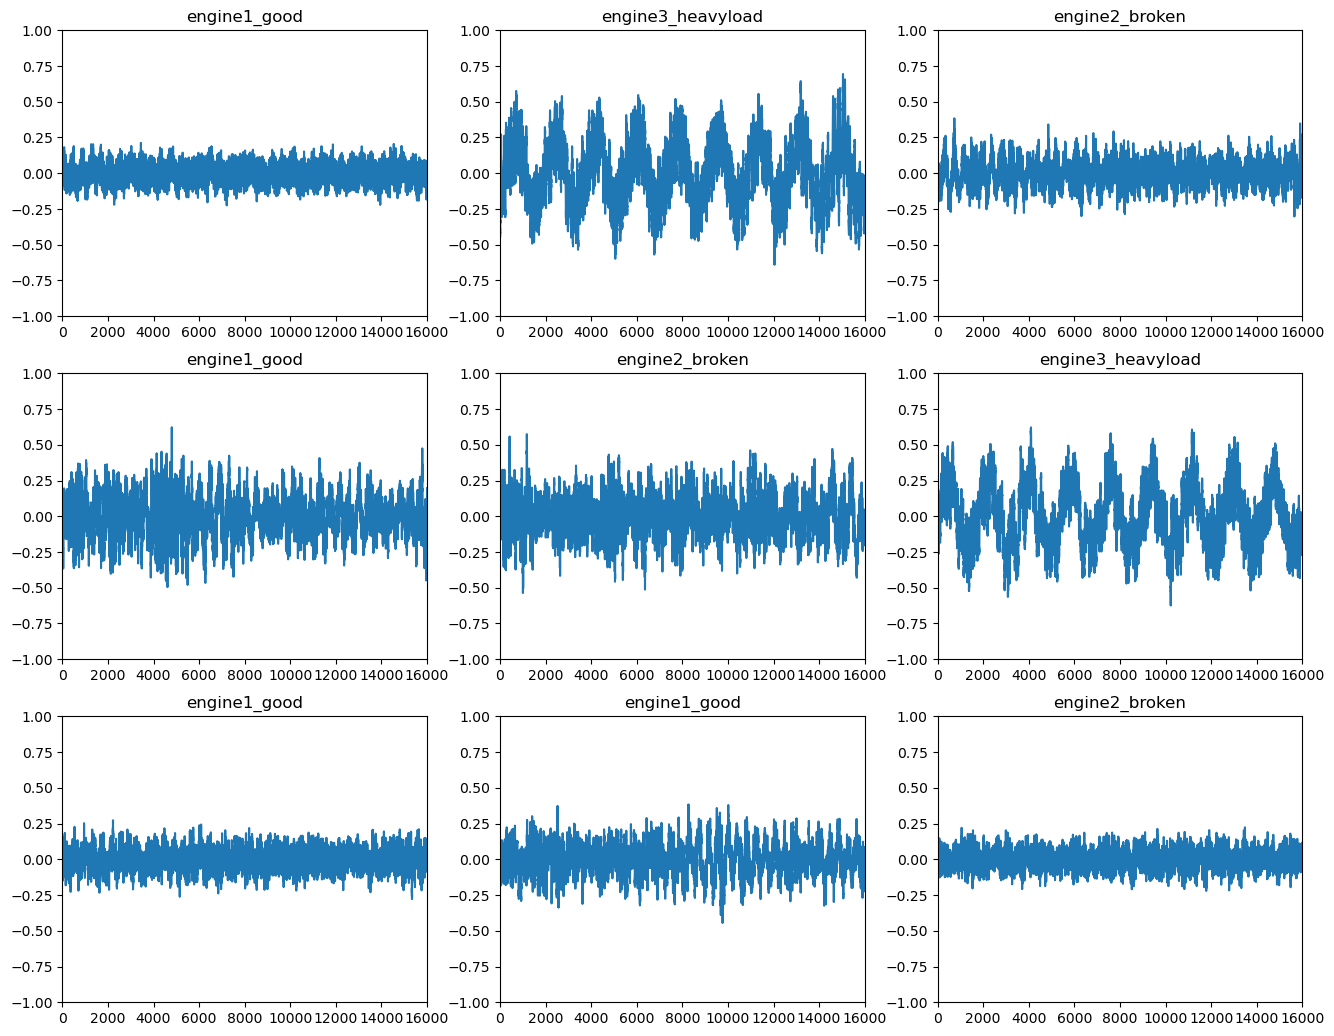

In [6]:
plt.figure(figsize=(16,9))
plt.subplots_adjust(bottom=-0.2)
for i in range(9):
  plt.subplot(3, 3, i+1)
  plt.plot(waveforms[i].numpy())
  plt.title(class_names[labels[i]])
  plt.axis([0, 16000, -1, 1])

In [7]:
spec = Spectrogram()

In [8]:
for j in range(6):
  label = class_names[labels[j]]
  waveform = waveforms[j]
  spectrogram = spec.get_spectrogram(waveform)
  print(f"\nLabel: {label}")
  print(f"Spectrogram Shape: {spectrogram.shape}\n")

  display.display(display.Audio(waveform, rate=16000))


Label: engine1_good
Spectrogram Shape: (124, 129, 1)




Label: engine3_heavyload
Spectrogram Shape: (124, 129, 1)




Label: engine2_broken
Spectrogram Shape: (124, 129, 1)




Label: engine1_good
Spectrogram Shape: (124, 129, 1)




Label: engine2_broken
Spectrogram Shape: (124, 129, 1)




Label: engine3_heavyload
Spectrogram Shape: (124, 129, 1)



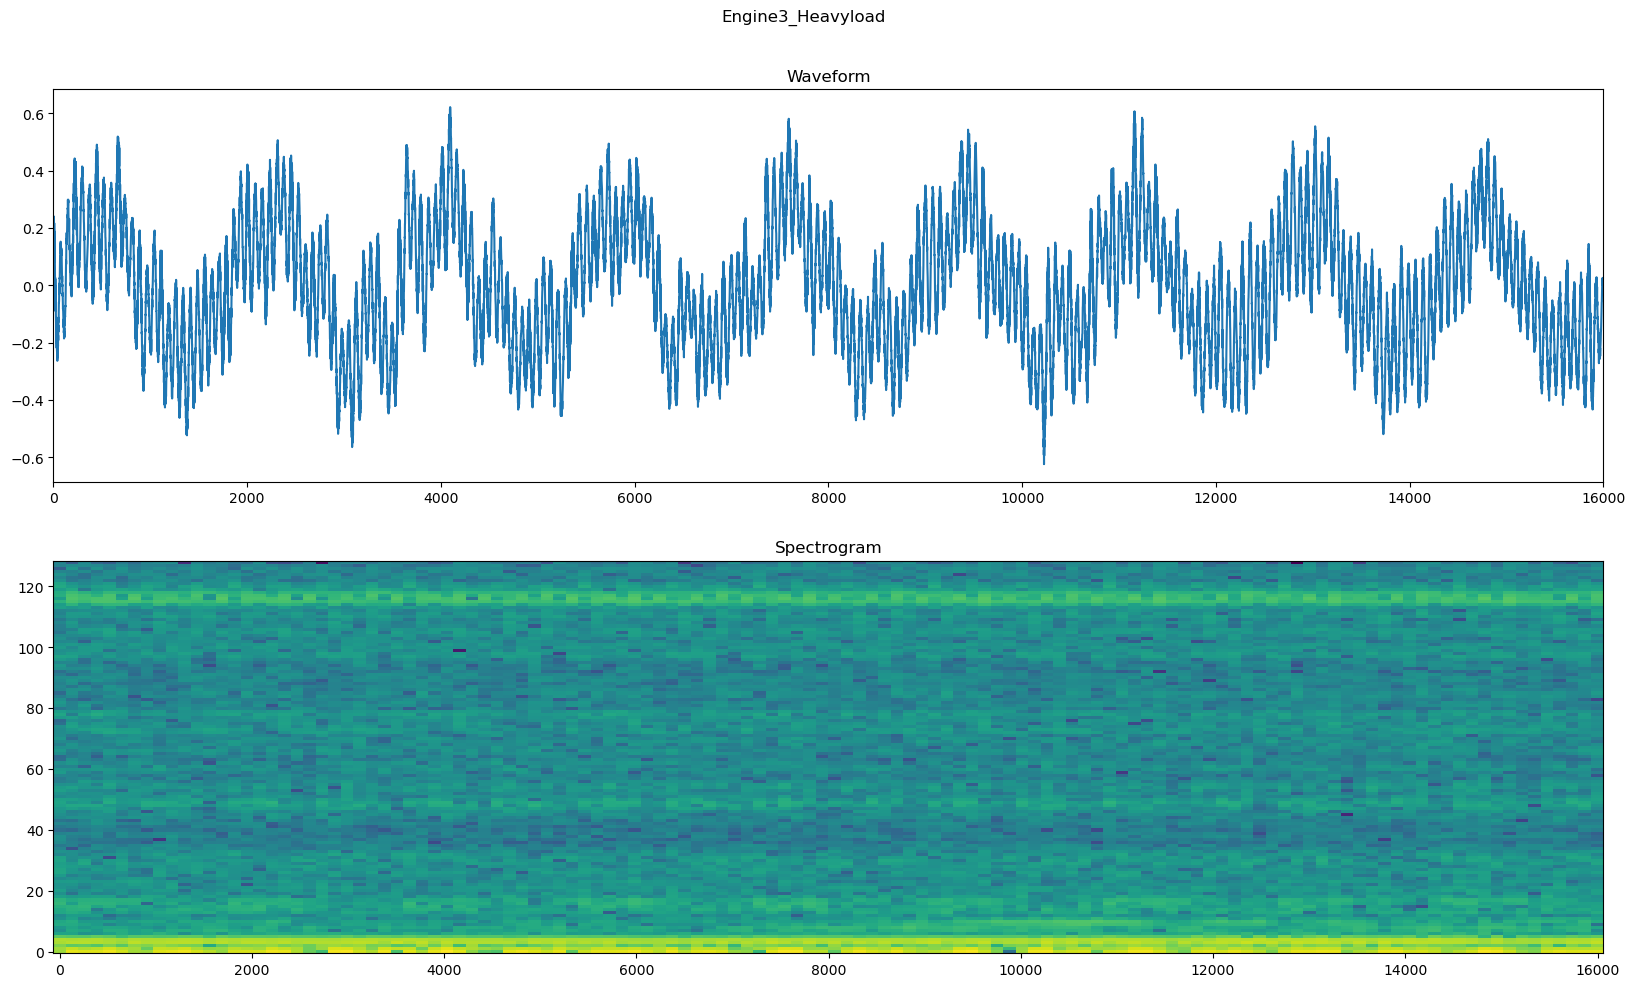

In [9]:
fig, axes = plt.subplots(2, figsize=(20, 8))
plt.subplots_adjust(bottom=-0.2)

timescale = np.arange(waveform.shape[0])
axes[0].plot(timescale, waveform.numpy())
axes[0].set_title('Waveform')
axes[0].set_xlim([0, 16000])

spec.plot_spectrogram(spectrogram.numpy(), axes[1])
axes[1].set_title('Spectrogram')
plt.suptitle(label.title())
plt.show()


In [10]:
train_spectrogram_ds = train_ds.map(
    map_func=lambda audio, label: (spec.get_spectrogram(audio), label),
    num_parallel_calls=tf.data.AUTOTUNE
)

validation_spectrogram_ds = validation_ds.map(
    map_func=lambda audio, label: (spec.get_spectrogram(audio), label),
    num_parallel_calls=tf.data.AUTOTUNE
)

test_spectrogram_ds = test_ds.map(
    map_func=lambda audio, label: (spec.get_spectrogram(audio), label),
    num_parallel_calls=tf.data.AUTOTUNE
)

for example_spectrograms, example_labels in train_spectrogram_ds.take(1):
  break

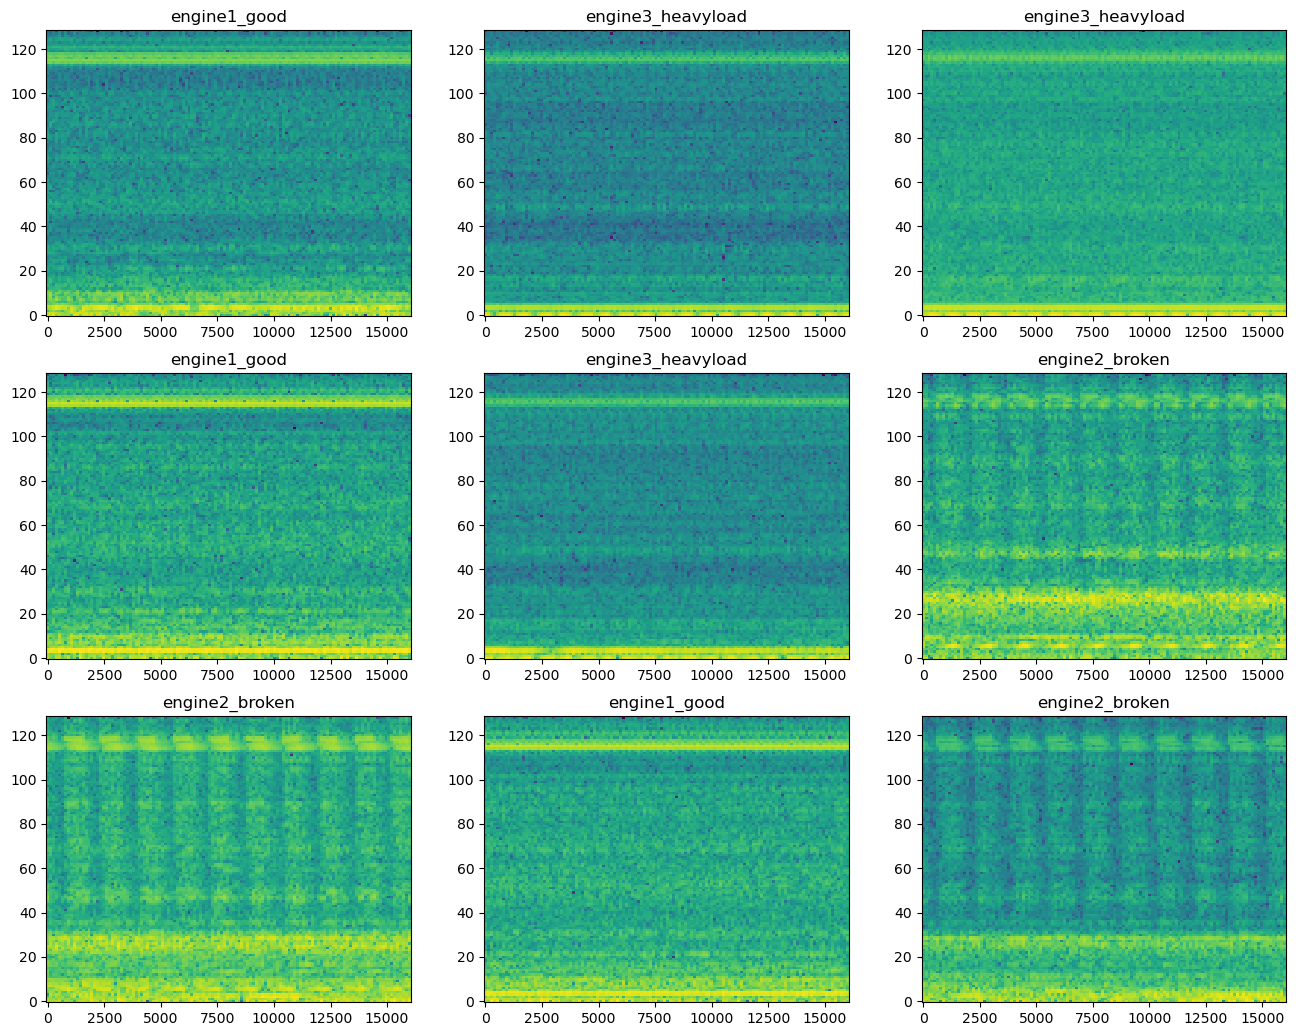

In [11]:
rows = 3
cols = 3
n = rows*cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 9))
plt.subplots_adjust(bottom=-0.2)

for i in range(n):
    r = i // cols
    c = i % cols
    ax = axes[r][c]
    spec.plot_spectrogram(example_spectrograms[i].numpy(), ax)
    ax.set_title(class_names[example_labels[i].numpy()])

plt.show()

In [12]:
train_spectrogram_ds = train_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)
validation_spectrogram_ds = validation_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)
test_spectrogram_ds = test_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)

#CREATE CNN MODEL 

In [14]:
input_shape = example_spectrograms.shape[1:]
print(input_shape)

num_labels = len(class_names)

normalization = tf.keras.layers.Normalization()

# Fit the state of the layer to the spectrograms
# with `Normalization.adapt`.
normalization.adapt(data=train_spectrogram_ds.map(map_func=lambda spec, label: spec))

model = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(input_shape=input_shape),
    tf.keras.layers.Resizing(32, 32),
    normalization,
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_labels)
])

model.summary()

(124, 129, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 32, 32, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,452,486 (9.36 MB)

 Trainable params: 2,452,483 (9.36 MB)

 Non-trainable params: 3 (16.00 B)

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [16]:
EPOCHS = 10

history = model.fit(
    train_spectrogram_ds,
    validation_data=validation_spectrogram_ds,
    epochs=EPOCHS
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.8754 - loss: 0.3587 - val_accuracy: 1.0000 - val_loss: 2.6842e-04
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9941 - loss: 0.0422 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9915 - loss: 0.0223 - val_accuracy: 1.0000 - val_loss: 1.5944e-05
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9967 - loss: 0.0114 - val_accuracy: 1.0000 - val_loss: 6.3055e-05
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9989 - loss: 0.0046 - val_accuracy: 1.0000 - val_loss: 3.8146e-06
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9992 - loss: 0.0055 - val_accuracy: 1.0000 - val_loss: 1.0121e-04
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9929 - loss: 0.0145 - val_accuracy: 1.0000 - val_loss: 7.8365e-06
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9988 - loss: 0.0026 - 

Text(0.5, 0, 'Epoch')

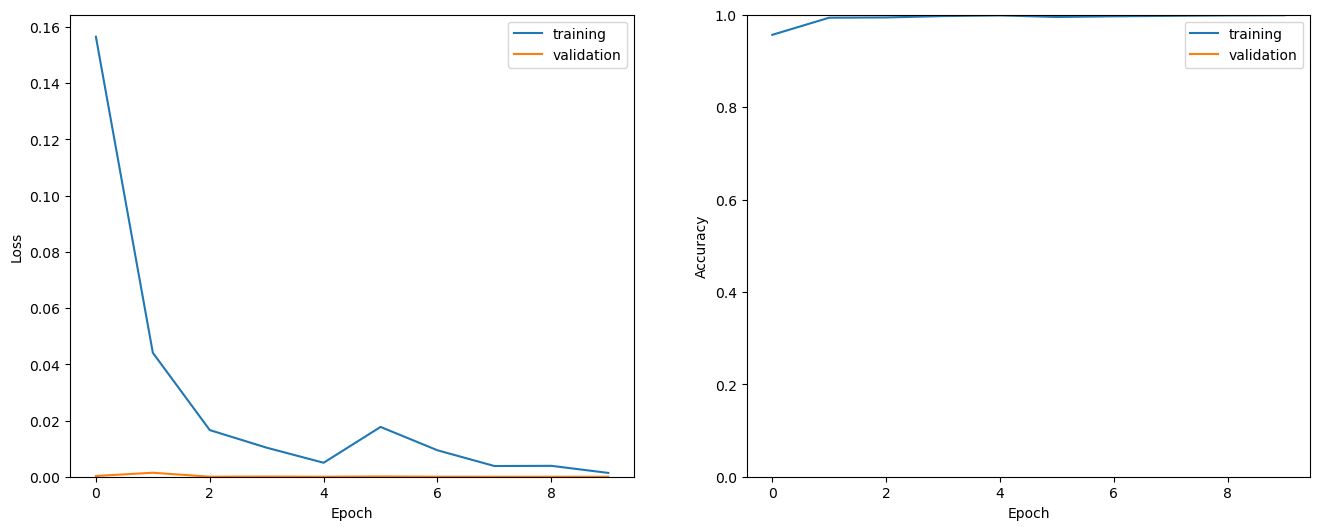

In [17]:
metrics = history.history
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.plot(history.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['training', 'validation'])
plt.ylim([0, max(plt.ylim())])
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.subplot(1, 2, 2)
plt.plot(history.epoch, metrics['accuracy'], metrics['val_accuracy'])
plt.legend(['training', 'validation'])
plt.ylim([0, 1])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

In [18]:
model.evaluate(test_spectrogram_ds, return_dict=True)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 4.3151e-08


{'accuracy': 1.0, 'loss': 5.091227350817462e-08}

In [19]:
y_pred = model.predict(test_spectrogram_ds)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [20]:
y_pred = tf.argmax(y_pred, axis=1)

In [21]:
y_true = tf.concat([y for x, y in test_spectrogram_ds], axis=0)

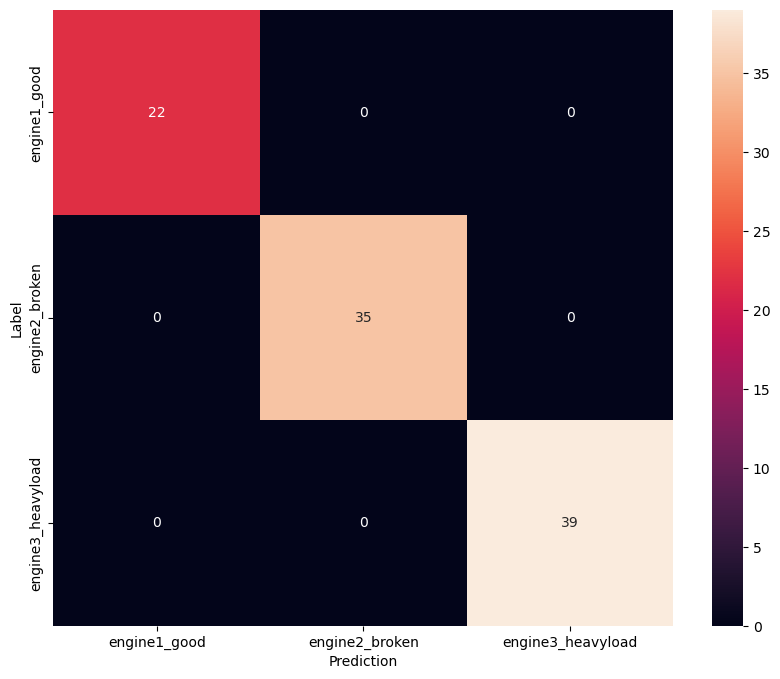

In [22]:
confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx,
            xticklabels=class_names,
            yticklabels=class_names,
            annot=True, fmt='g')
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()

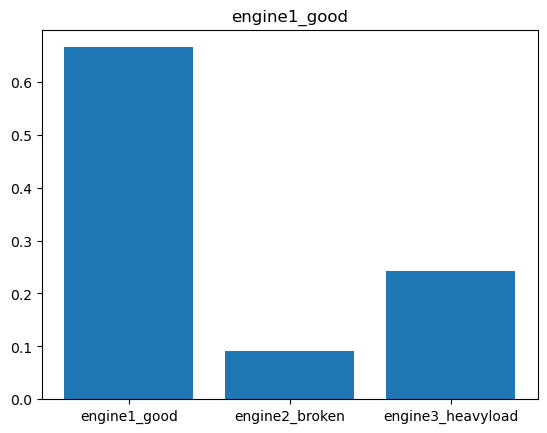

In [ ]:
x = "data set path here"
x = tf.io.read_file(str(x))
x, sample_rate = tf.audio.decode_wav(x, desired_channels=1, desired_samples=16000,)
x = tf.squeeze(x, axis=-1)
waveform = x
x = spec.get_spectrogram(x)
x = x[tf.newaxis,...]

prediction = model(x)
x_labels = ['engine1_good', 'engine2_broken', 'engine3_heavyload']
plt.bar(x_labels, tf.nn.softmax(prediction[0]))
plt.title('engine1_good')
plt.show()

display.display(display.Audio(waveform, rate=16000))

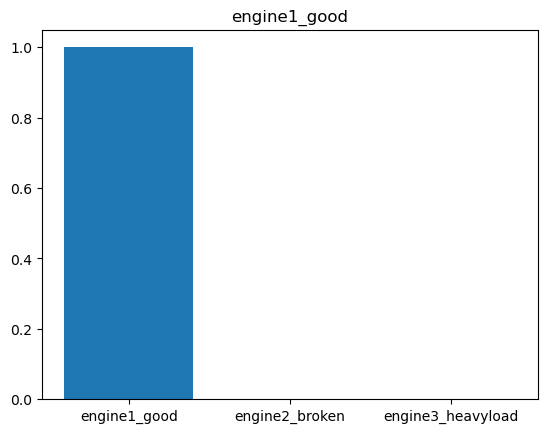

In [ ]:
x = "data set path here"
x = tf.io.read_file(str(x))
x, sample_rate = tf.audio.decode_wav(x, desired_channels=1, desired_samples=16000,)
x = tf.squeeze(x, axis=-1)
waveform = x
x = spec.get_spectrogram(x)
x = x[tf.newaxis,...]

prediction = model(x)
x_labels = ['engine1_good', 'engine2_broken', 'engine3_heavyload']
plt.bar(x_labels, tf.nn.softmax(prediction[0]))
plt.title('engine1_good')
plt.show()

display.display(display.Audio(waveform, rate=16000))

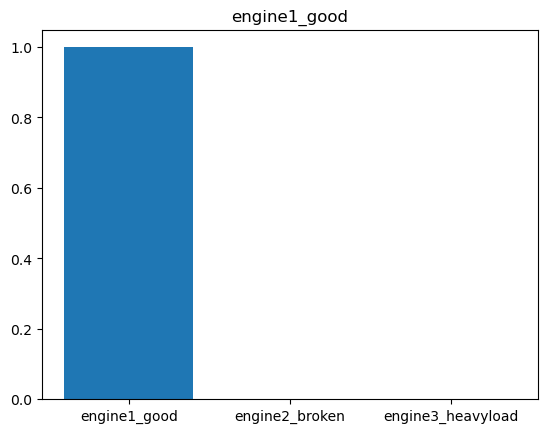

In [ ]:
x = "data set path here"
x = tf.io.read_file(str(x))
x, sample_rate = tf.audio.decode_wav(x, desired_channels=1, desired_samples=16000,)
x = tf.squeeze(x, axis=-1)
waveform = x
x = spec.get_spectrogram(x)
x = x[tf.newaxis,...]

prediction = model(x)
x_labels = ['engine1_good', 'engine2_broken', 'engine3_heavyload']
plt.bar(x_labels, tf.nn.softmax(prediction[0]))
plt.title('engine1_good')
plt.show()

display.display(display.Audio(waveform, rate=16000))

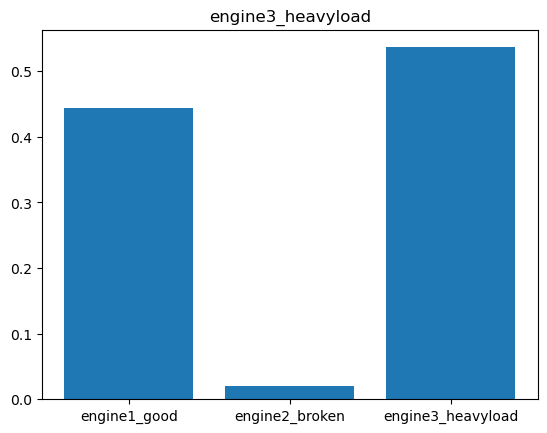

In [ ]:
x = "data set path here"
x = tf.io.read_file(str(x))
x, sample_rate = tf.audio.decode_wav(x, desired_channels=1, desired_samples=16000,)
x = tf.squeeze(x, axis=-1)
waveform = x
x = spec.get_spectrogram(x)
x = x[tf.newaxis,...]

prediction = model(x)
x_labels = ['engine1_good', 'engine2_broken', 'engine3_heavyload']
plt.bar(x_labels, tf.nn.softmax(prediction[0]))
plt.title('engine3_heavyload')
plt.show()

display.display(display.Audio(waveform, rate=16000))

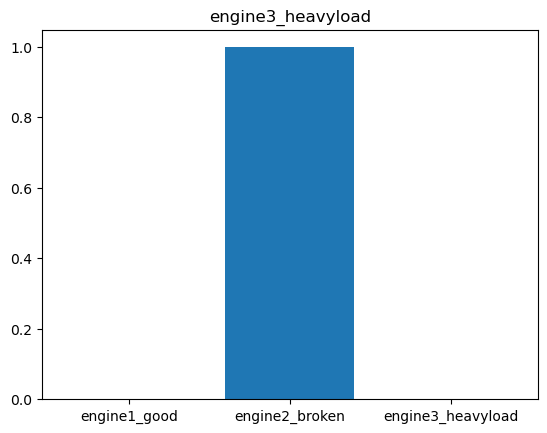

In [ ]:
x = "data set path here"
x = tf.io.read_file(str(x))
x, sample_rate = tf.audio.decode_wav(x, desired_channels=1, desired_samples=16000,)
x = tf.squeeze(x, axis=-1)
waveform = x
x = spec.get_spectrogram(x)
x = x[tf.newaxis,...]

prediction = model(x)
x_labels = ['engine1_good', 'engine2_broken', 'engine3_heavyload']
plt.bar(x_labels, tf.nn.softmax(prediction[0]))
plt.title('engine3_heavyload')
plt.show()

display.display(display.Audio(waveform, rate=16000))

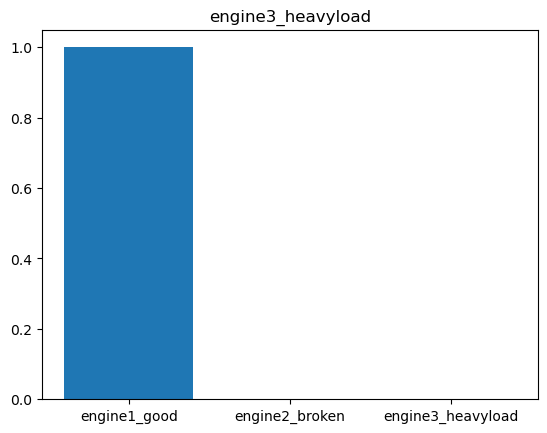

In [ ]:
x = "data set path here"
x = tf.io.read_file(str(x))
x, sample_rate = tf.audio.decode_wav(x, desired_channels=1, desired_samples=16000,)
x = tf.squeeze(x, axis=-1)
waveform = x
x = spec.get_spectrogram(x)
x = x[tf.newaxis,...]

prediction = model(x)
x_labels = ['engine1_good', 'engine2_broken', 'engine3_heavyload']
plt.bar(x_labels, tf.nn.softmax(prediction[0]))
plt.title('engine3_heavyload')
plt.show()

display.display(display.Audio(waveform, rate=16000))

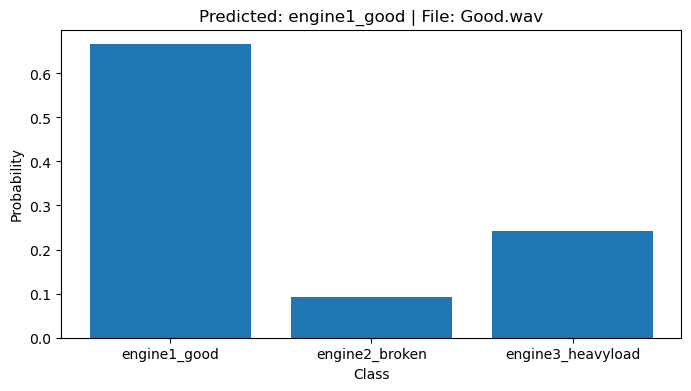

File: Good.wav | Predicted: engine1_good


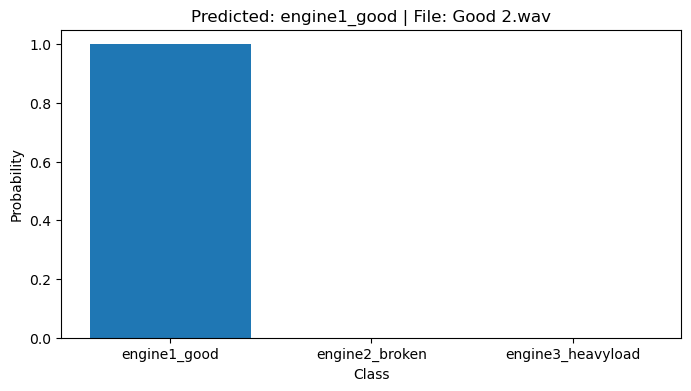

File: Good 2.wav | Predicted: engine1_good


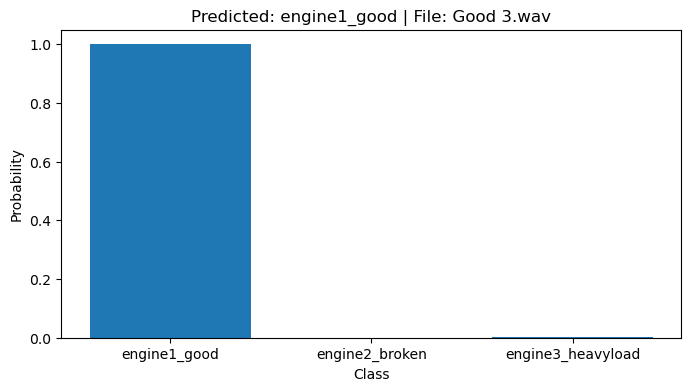

File: Good 3.wav | Predicted: engine1_good


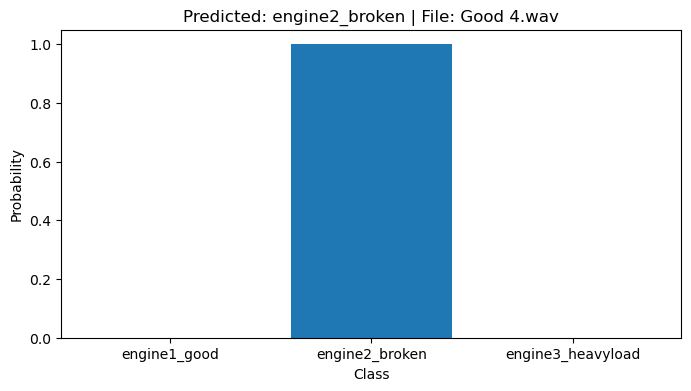

File: Good 4.wav | Predicted: engine2_broken


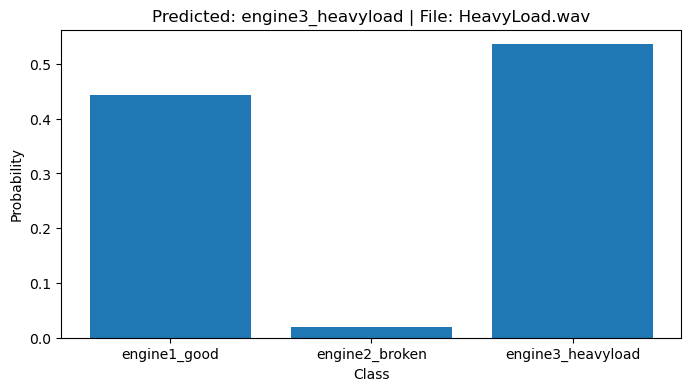

File: HeavyLoad.wav | Predicted: engine3_heavyload


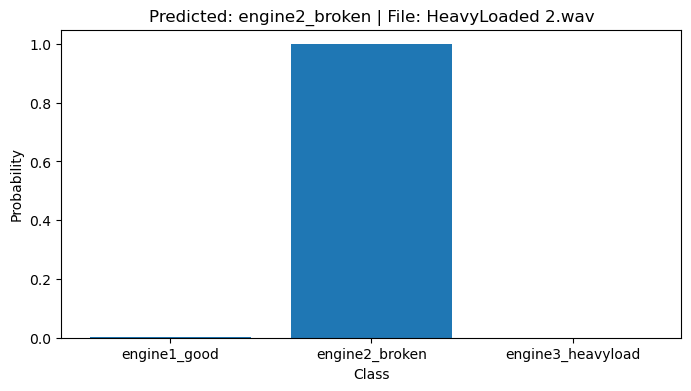

File: HeavyLoaded 2.wav | Predicted: engine2_broken


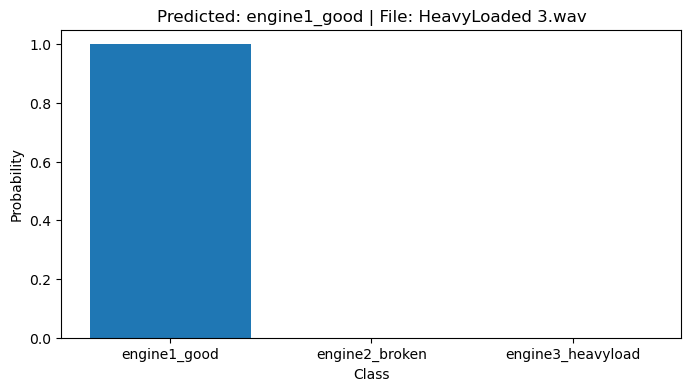

File: HeavyLoaded 3.wav | Predicted: engine1_good


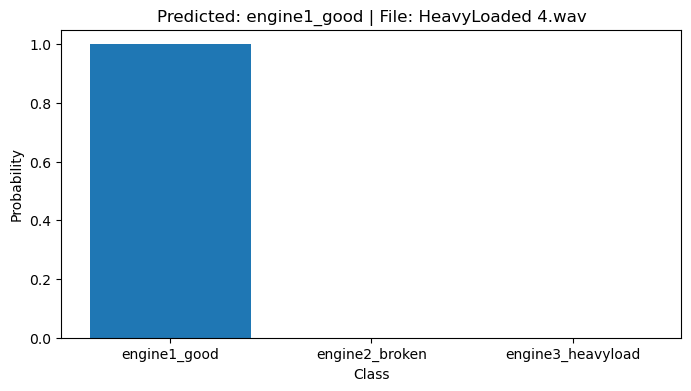

File: HeavyLoaded 4.wav | Predicted: engine1_good


In [ ]:
def predict_and_visualize(file_path, model, spectrogram_obj, class_names, sample_rate=16000):
    try:
        # Read and preprocess audio file
        audio = tf.io.read_file(str(file_path))
        audio, _ = tf.audio.decode_wav(audio, desired_channels=1, desired_samples=16000)
        audio = tf.squeeze(audio, axis=-1)
        
        # Generate spectrogram
        spectrogram = spectrogram_obj.get_spectrogram(audio)
        spectrogram = spectrogram[tf.newaxis, ...]
        
        # Predict
        prediction = model(spectrogram)
        probabilities = tf.nn.softmax(prediction[0]).numpy()
        predicted_class = class_names[tf.argmax(prediction, axis=1).numpy()[0]]
        
        # Visualize
        plt.figure(figsize=(8, 4))
        plt.bar(class_names, probabilities)
        plt.title(f'Predicted: {predicted_class} | File: {os.path.basename(file_path)}')
        plt.xlabel('Class')
        plt.ylabel('Probability')
        plt.show()
        
        # Play audio
        display.display(display.Audio(audio, rate=sample_rate))
        
        return predicted_class, probabilities
    
    except Exception as e:
        print(f"Error processing {file_path}: {str(e)}")
        return None, None

# Example usage
test_files = [
    "data set path here",
    "data set path here",
    "data set path here",
    "data set path here",
    "data set path here",
    "data set path here",
    "data set path here",
    "data set path here"

]

for file in test_files:
    predicted_class, probabilities = predict_and_visualize(file, model, spec, x_labels)
    if predicted_class:
        print(f"File: {os.path.basename(file)} | Predicted: {predicted_class}")
